In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
df = pd.read_csv("ecommerce_sales.csv")

In [4]:
df

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,14996,9/5/2035,1289,Clothing,West,2,371.74,0.27,COD,3,2.3,542.74
4996,14997,9/6/2035,1294,Beauty,North,3,553.67,0.14,COD,11,2.2,1428.47
4997,14998,9/7/2035,1450,Beauty,West,3,77.22,0.24,Wallet,6,3.4,176.06
4998,14999,9/8/2035,1903,Electronics,South,4,138.41,0.21,COD,4,2.8,437.38


In [14]:
df.shape

(5000, 12)

In [5]:
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   object 
 4   region            5000 non-null   object 
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   object 
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB


In [10]:
#Missing Values 
df.isnull().sum()

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

In [8]:
df.describe()

,order_id,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,1505.701200,4.044800,308.418774,0.179984,6.118800,2.973980,1021.955148
std,1443.520003,290.836902,2.020398,169.259369,0.101404,3.153264,1.157722,825.584219
min,10001.000000,1000.000000,1.000000,15.150000,0.000000,1.000000,1.000000,11.210000
25%,11250.750000,1253.000000,2.000000,161.895000,0.090000,3.000000,2.000000,354.527500
50%,12500.500000,1510.000000,4.000000,309.890000,0.180000,6.000000,3.000000,796.650000
75%,13750.250000,1761.000000,6.000000,455.557500,0.270000,9.000000,4.000000,1515.690000
max,15000.000000,1999.000000,7.000000,599.960000,0.350000,11.000000,5.000000,4119.330000


In [11]:
# Duplicates
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Length: 5000, dtype: bool

In [12]:
df.duplicated().sum()

np.int64(0)

In [16]:
#convert date column
df['order_date'] = pd.to_datetime(df['order_date'])


REVENUE BY CATEGORY
product_category
Beauty          765860.88
Clothing       1531931.72
Electronics    1829899.22
Home            982083.92
Name: revenue, dtype: float64


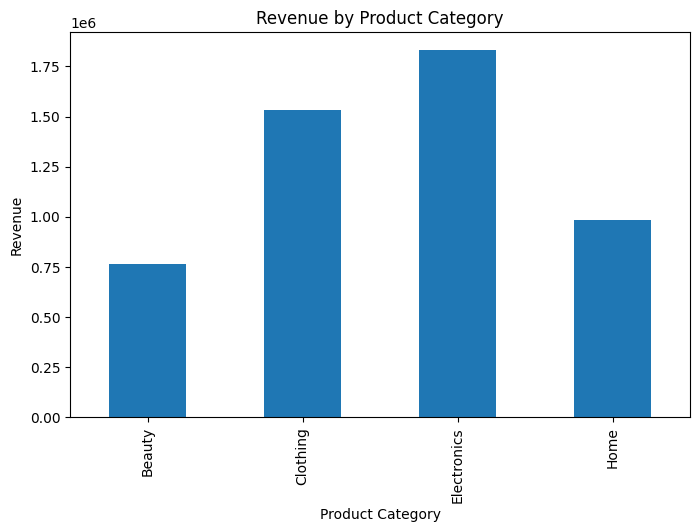

In [17]:
category_revenue = df.groupby('product_category')['revenue'].sum()

print("\nREVENUE BY CATEGORY")
print(category_revenue)

plt.figure(figsize=(8,5))
category_revenue.plot(kind='bar')
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.show()

#Revenue by Product Category


 REGION-WISE SALES
region
East     1236044.23
North    1281508.45
South    1246640.90
West     1345582.16
Name: revenue, dtype: float64


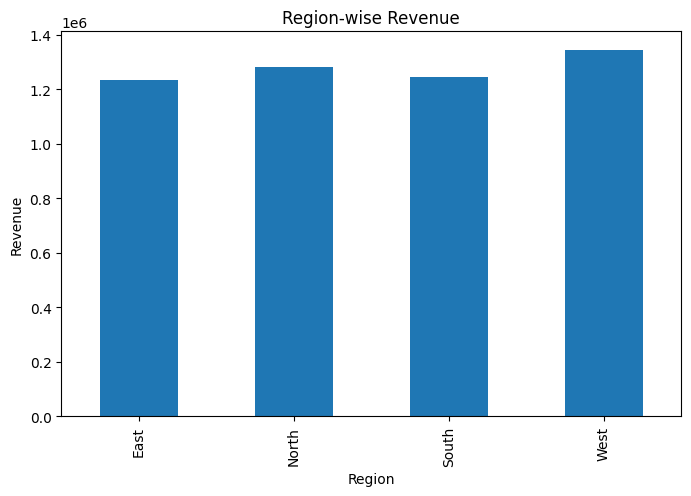

In [18]:
region_sales = df.groupby('region')['revenue'].sum()

print("\n REGION-WISE SALES")
print(region_sales)

plt.figure(figsize=(8,5))
region_sales.plot(kind='bar')
plt.title("Region-wise Revenue")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.show()

#Region-wise Sales Analysis


 PAYMENT METHOD DISTRIBUTION 
payment_method
Card      2270
COD       1774
Wallet     956
Name: count, dtype: int64


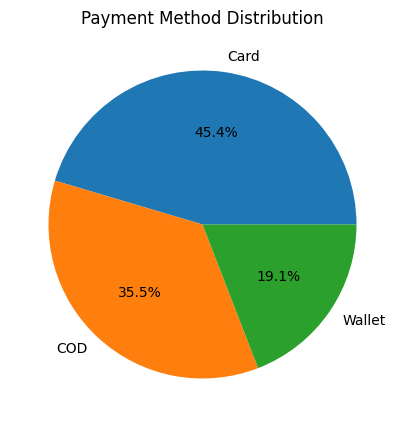

In [19]:
payment_counts = df['payment_method'].value_counts()

print("\n PAYMENT METHOD DISTRIBUTION ")
print(payment_counts)

plt.figure(figsize=(8,5))
payment_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Method Distribution")
plt.ylabel("")
plt.show()

#Payment Method Distribution



 CORRELATION MATRIX 
                 order_id  customer_id  quantity  unit_price  discount  \
order_id         1.000000     0.017504 -0.003368    0.017876  0.011110   
customer_id      0.017504     1.000000  0.023097    0.009748 -0.012617   
quantity        -0.003368     0.023097  1.000000    0.001498 -0.004302   
unit_price       0.017876     0.009748  0.001498    1.000000  0.013215   
discount         0.011110    -0.012617 -0.004302    0.013215  1.000000   
delivery_days    0.006196    -0.017440 -0.008748    0.015623 -0.000382   
customer_rating  0.004984     0.020302  0.019168    0.005025  0.012776   
revenue          0.009681     0.025499  0.623564    0.678032 -0.139296   

                 delivery_days  customer_rating   revenue  
order_id              0.006196         0.004984  0.009681  
customer_id          -0.017440         0.020302  0.025499  
quantity             -0.008748         0.019168  0.623564  
unit_price            0.015623         0.005025  0.678032  
discount   

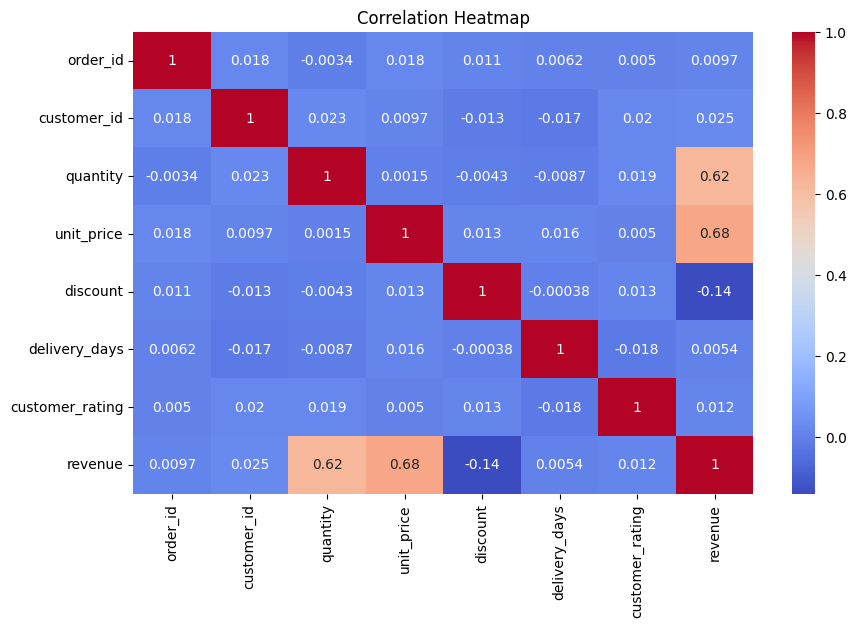

In [20]:
numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

print("\n CORRELATION MATRIX ")
print(correlation_matrix)

plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#Correlation Analysis

In [21]:
print("\n HYPOTHESIS TESTING ")

# Hypothesis 1
print("\nHypothesis 1:")
print("Higher-priced products generate higher revenue.")

corr_price_revenue = df['unit_price'].corr(df['revenue'])

print("Correlation between Unit Price and Revenue:")
print(corr_price_revenue)

# Hypothesis 2
print("\nHypothesis 2:")
print("Discount affects revenue.")

corr_discount_revenue = df['discount'].corr(df['revenue'])

print("Correlation between Discount and Revenue:")
print(corr_discount_revenue)

# Hypothesis 3
print("\nHypothesis 3:")
print("Customer rating affects revenue.")

corr_rating_revenue = df['customer_rating'].corr(df['revenue'])

print("Correlation between Customer Rating and Revenue:")
print(corr_rating_revenue)



 HYPOTHESIS TESTING 

Hypothesis 1:
Higher-priced products generate higher revenue.
Correlation between Unit Price and Revenue:
0.6780323736024381

Hypothesis 2:
Discount affects revenue.
Correlation between Discount and Revenue:
-0.1392956029673074

Hypothesis 3:
Customer rating affects revenue.
Correlation between Customer Rating and Revenue:
0.012445926504080707


#Hypothesis Testing

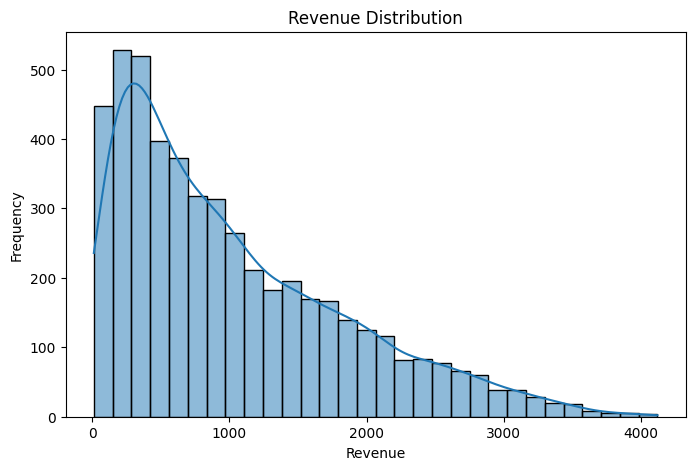

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df['revenue'], bins=30, kde=True)
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()


#Revenue Distribution


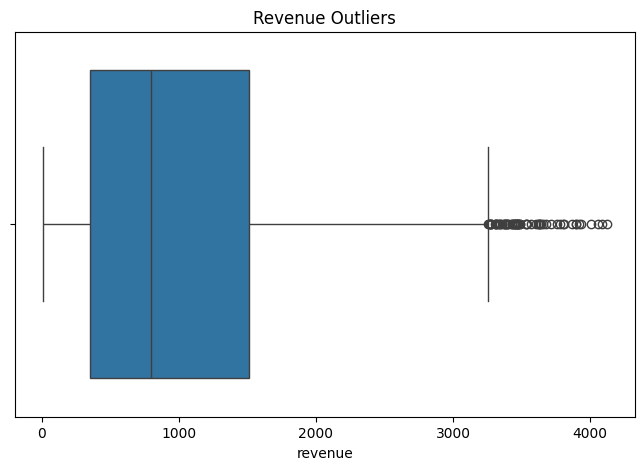

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['revenue'])
plt.title("Revenue Outliers")
plt.show()


#Outlier Detection using Boxplot

In [24]:
Q1 = df['revenue'].quantile(0.25)
Q3 = df['revenue'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['revenue'] < lower_bound) |
    (df['revenue'] > upper_bound)
]

print("\n OUTLIERS ")
print("Number of Outliers:", outliers.shape[0])


 OUTLIERS 
Number of Outliers: 67


#Detect Outliers using IQR

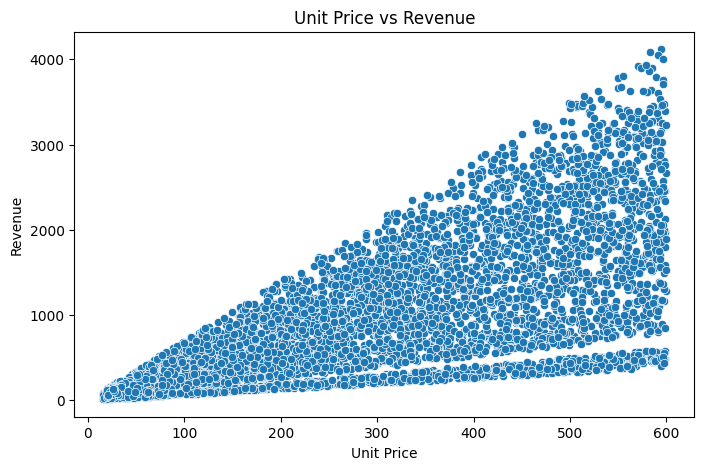

In [26]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='unit_price', y='revenue', data=df)
plt.title("Unit Price vs Revenue")
plt.xlabel("Unit Price")
plt.ylabel("Revenue")
plt.show()

 #Scatter Plot Analysis

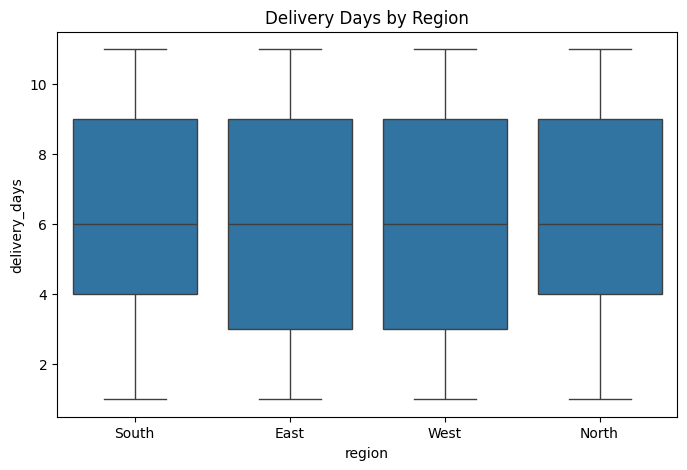

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(x='region', y='delivery_days', data=df)
plt.title("Delivery Days by Region")
plt.show()


#Delivery Days Analysis